# Hedonic Regression Model — Orthogonalized Architecture (GBM Quality Block)

Перестроенная модель с **разделёнными блоками**, чтобы geo-фичи не душились district one-hots.

## Новая архитектура (orthogonalization)

```
log_price_sqm = market(quarter) + geo_score + quality_score + project_premium + ε
```

Каждый блок видит **только свои фичи** и объясняет **остаток** после предыдущих:

1. **Market block** — только квартальный тренд по городу (без district).
2. **Geo block** — собственный регрессор на geo-фичах → даёт `geo_score`.
3. **Quality block** — объектные фичи (площадь, этаж, класс, застройщик) БЕЗ district и БЕЗ geo.
4. **Project premium** — shrinkage на проект.
5. **Final fit** — ElasticNet поверх всех блоков для калибровки.

## Почему это работает

В старой модели `district_final` (~145 one-hot колонок) поглощал весь пространственный сигнал, а geo-фичи обнулялись ElasticNet'ом как избыточные. Теперь geo-блок **обязан** объяснить пространственную вариацию — у него нет конкурентов.

> **v3-GBM**: Quality Block (Блок 3) заменён с RidgeCV на HistGradientBoostingRegressor.
> Остальные блоки (market, geo, project_premium) идентичны hedonic_modelv3.ipynb.
> Подробное исследование: `project_part/research_quality_block.ipynb`


## 0. Импорты

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 300
pd.options.display.width = 220
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

## 1. Пути к данным

In [2]:
PROJECT_DIR = Path("/root/cashflow_project")
REGION_KEY  = "Moscow"

GEO_ENRICHED_PATH = Path("C:\\proga\\gazprom_tex\\data\\deals_with_real_geo_Moscow.parquet")

print(f"Входной файл: {GEO_ENRICHED_PATH}")
print(f"Файл существует: {GEO_ENRICHED_PATH.exists()}")

Входной файл: C:\proga\gazprom_tex\data\deals_with_real_geo_Moscow.parquet
Файл существует: True


## 2. Загрузка обогащённых данных

In [3]:
deals = pd.read_parquet(GEO_ENRICHED_PATH)
print(f"deals shape: {deals.shape}")
display(deals[["project_name", "district_final", "deal_date", "area_sqm", "price_sqm", "log_price_sqm"]].head(3))

deals shape: (577405, 69)


,project_name,district_final,deal_date,area_sqm,price_sqm,log_price_sqm
0,Руставели 14,Бутырский,2002-11-12,34.40,468204.0,13.056659
1,Первый Дубровский,Южнопортовый,2015-01-05,58.31,271125.0,12.510335
2,Савеловский Сити,Бутырский,2015-04-18,67.20,207013.0,12.240537


## 3. Утилиты

In [4]:
def mode_or_nan(x: pd.Series):
    x = x.dropna()
    if x.empty:
        return np.nan
    m = x.mode()
    return m.iloc[0] if not m.empty else x.iloc[0]


def regression_metrics(y_true, y_pred, name="model"):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return pd.DataFrame([{
        "model":           name,
        "MAE_log":         mae,
        "RMSE_log":        rmse,
        "R2":              r2,
        "MAE_pct_approx":  100 * (np.exp(mae) - 1),
        "RMSE_pct_approx": 100 * (np.exp(rmse) - 1),
    }])


def sanitize_for_sklearn(df, num_cols, cat_cols):
    df = df.copy()
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
    df[cat_cols] = df[cat_cols].astype("object")
    return df.replace({pd.NA: np.nan})


def extract_coefs(model, num_cols, cat_cols):
    """Извлекает коэффициенты пайплайна с ColumnTransformer.
    Работает и когда cat_cols пустой (нет OHE)."""
    reg = model.named_steps["reg"]
    prep = model.named_steps["prep"]

    cat_names = []
    if cat_cols and "cat" in prep.named_transformers_:
        cat_names = list(
            prep.named_transformers_["cat"].named_steps["ohe"]
            .get_feature_names_out(cat_cols)
        )

    all_names = list(num_cols) + cat_names
    return pd.Series(reg.coef_, index=all_names)

## 4. Train/test split по кварталам

Делаем split **до** обучения всех блоков, чтобы избежать data leakage: market, geo, quality, premium обучаются только на train.

In [5]:
quarters_sorted = sorted(deals["quarter"].dropna().unique().tolist())
split_idx       = max(1, int(len(quarters_sorted) * 0.7))
train_quarters  = set(quarters_sorted[:split_idx])
test_quarters   = set(quarters_sorted[split_idx:])

train_mask = deals["quarter"].isin(train_quarters)
test_mask  = deals["quarter"].isin(test_quarters)

print(f"train quarters: {sorted(train_quarters)[:3]} ... {sorted(train_quarters)[-3:]}")
print(f"test quarters : {sorted(test_quarters)[:3]} ... {sorted(test_quarters)[-3:]}")
print(f"train rows    : {train_mask.sum():,}")
print(f"test rows     : {test_mask.sum():,}")

train quarters: ['2002Q4', '2015Q1', '2015Q2'] ... ['2022Q1', '2022Q2', '2022Q3']
test quarters : ['2022Q4', '2023Q1', '2023Q2'] ... ['2025Q3', '2025Q4', '2026Q1']
train rows    : 345,566
test rows     : 231,839


## 5. Блок 1 — market block (только квартальный тренд по городу)

**Важное изменение:** убираем district из market-блока. Теперь market_log_price содержит только временной тренд, а всю пространственную вариацию обязан объяснить geo_block.

$$m_t = \widetilde y_{city,t}$$

Считаем медианы **только на train**, чтобы избежать утечки из будущего.

In [6]:
# ── ШАГ 1: медианы квартала ТОЛЬКО на train ─────────────────────────────
city_q_train = (
    deals.loc[train_mask]
    .groupby("quarter", as_index=False)
    .agg(
        city_log_price_median=("log_price_sqm", "median"),
        city_n=("log_price_sqm", "size"),
    )
)

# ── ШАГ 2: damped linear trend по последним N кварталам train ───────────
all_quarters_sorted = sorted(deals["quarter"].dropna().unique().tolist())
quarter_to_idx = {q: i for i, q in enumerate(all_quarters_sorted)}
deals["quarter_idx"] = deals["quarter"].map(quarter_to_idx)
city_q_train["quarter_idx"] = city_q_train["quarter"].map(quarter_to_idx)

N_RECENT_Q  = 12    # окно для оценки наклона
DAMPING_PHI = 0.85  # затухание тренда при экстраполяции (1.0 = без затухания)

recent_q = city_q_train.sort_values("quarter_idx").tail(N_RECENT_Q)
x = recent_q["quarter_idx"].values.astype(float)
y = recent_q["city_log_price_median"].values.astype(float)
w = recent_q["city_n"].values.astype(float)

x_mean = np.average(x, weights=w)
y_mean = np.average(y, weights=w)
cov_xy = np.average((x - x_mean) * (y - y_mean), weights=w)
var_x  = np.average((x - x_mean) ** 2, weights=w)
slope = cov_xy / var_x
intercept = y_mean - slope * x_mean

last_train_idx    = city_q_train["quarter_idx"].max()
last_train_fitted = intercept + slope * last_train_idx

print(f"Линейный тренд (последние {N_RECENT_Q} кв. train):")
print(f"  slope      : {slope:.4f}  (~{100*(np.exp(slope)-1):.2f}% / кв.)")
print(f"  damping φ  : {DAMPING_PHI}")
print(f"  last train quarter idx: {last_train_idx}")


def extrapolate_damped(q_idx):
    """Damped trend: линейный фит внутри train, затухающая экстраполяция на test."""
    if pd.isna(q_idx):
        return np.nan
    if q_idx <= last_train_idx:
        return intercept + slope * q_idx
    h = q_idx - last_train_idx
    damped_sum = DAMPING_PHI * (1 - DAMPING_PHI**h) / (1 - DAMPING_PHI)
    return last_train_fitted + slope * damped_sum


deals["market_trend"] = deals["quarter_idx"].map(extrapolate_damped)

# ── ШАГ 3: формируем market_log_price ────────────────────────────────────
# Для train-кварталов — фактическая медиана train
# Для test-кварталов — damped trend
drop_cols = ["city_log_price_median", "city_n", "market_log_price", "market_residual",
             "district_log_price_median", "district_n", "market_weight"]
deals = deals.drop(columns=[c for c in drop_cols if c in deals.columns])

deals = deals.merge(
    city_q_train[["quarter", "city_log_price_median"]], on="quarter", how="left"
)
deals["market_log_price"] = deals["city_log_price_median"].fillna(deals["market_trend"])
deals["market_residual"]  = deals["log_price_sqm"] - deals["market_log_price"]

# ── Диагностика ──────────────────────────────────────────────────────────
r2_market_train = 1 - deals.loc[train_mask, "market_residual"].var() / deals.loc[train_mask, "log_price_sqm"].var()
r2_market_test  = 1 - deals.loc[test_mask, "market_residual"].var() / deals.loc[test_mask, "log_price_sqm"].var()
print(f"\nR² market-блока (train): {r2_market_train:.4f}")
print(f"R² market-блока (test) : {r2_market_test:.4f}")
print(f"market_residual std (train): {deals.loc[train_mask, 'market_residual'].std():.4f}")
print(f"market_residual std (test) : {deals.loc[test_mask, 'market_residual'].std():.4f}")

bias_test = deals.loc[test_mask, "market_residual"].mean()
print(f"\nСредний bias на test: {bias_test:+.4f}  ({100*(np.exp(bias_test)-1):+.2f}%)")
print(f"  (>0 → тренд недооценил, <0 → тренд переоценил)")

n_actual = deals["city_log_price_median"].notna().sum()
n_extrap = deals["city_log_price_median"].isna().sum()
print(f"\nПокрытие market_log_price:")
print(f"  фактическая медиана train: {n_actual:,} сделок")
print(f"  экстраполяция тренда     : {n_extrap:,} сделок")

district_spread = (
    deals.loc[train_mask].groupby("district_final")["market_residual"]
    .agg(["mean", "count"]).sort_values("mean")
)
print(f"\nПространственный сигнал для geo-блока:")
print(f"  Диапазон средних остатков по районам: [{district_spread['mean'].min():.3f}, {district_spread['mean'].max():.3f}]")
print(f"  Std средних остатков:                  {district_spread['mean'].std():.3f}")

Линейный тренд (последние 12 кв. train):
  slope      : 0.0428  (~4.37% / кв.)
  damping φ  : 0.85
  last train quarter idx: 31

R² market-блока (train): 0.3556
R² market-блока (test) : 0.0919
market_residual std (train): 0.3192
market_residual std (test) : 0.3363

Средний bias на test: +0.0429  (+4.39%)
  (>0 → тренд недооценил, <0 → тренд переоценил)

Покрытие market_log_price:
  фактическая медиана train: 345,566 сделок
  экстраполяция тренда     : 231,839 сделок

Пространственный сигнал для geo-блока:
  Диапазон средних остатков по районам: [-0.506, 1.311]
  Std средних остатков:                  0.357


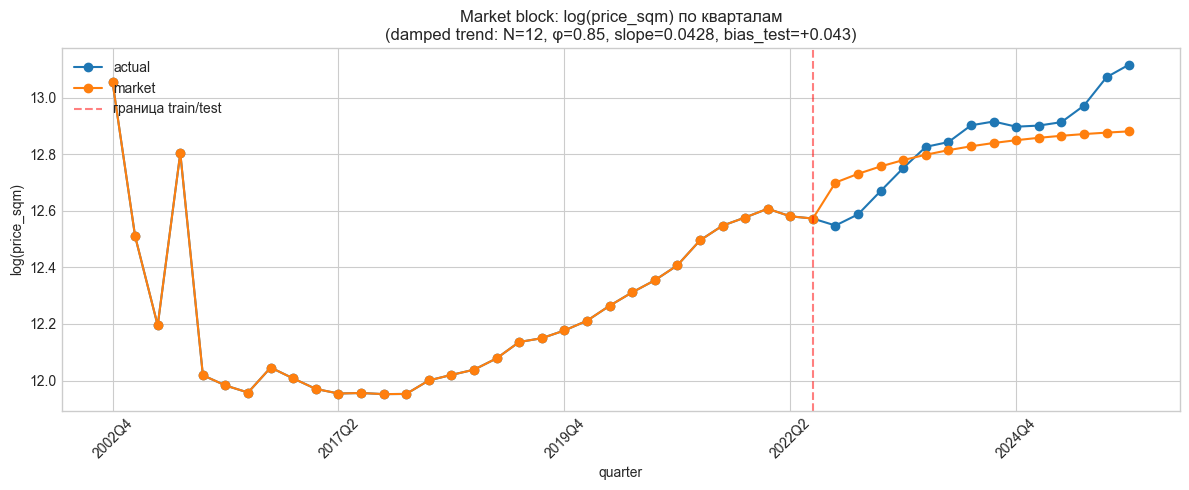

In [7]:
market_diag = (
    deals.groupby("quarter", as_index=False)
    .agg(
        actual=("log_price_sqm", "median"),
        market=("market_log_price", "median"),
    )
    .sort_values("quarter")
    .reset_index(drop=True)
)

last_train_q = max(train_quarters)
split_pos    = market_diag.index[market_diag["quarter"] == last_train_q][0]

fig, ax = plt.subplots(figsize=(12, 5))
market_diag.plot(x="quarter", y=["actual", "market"], marker="o", ax=ax)
ax.axvline(x=split_pos, color="red", linestyle="--", alpha=0.5, label="граница train/test")
ax.set_title(
    f"Market block: log(price_sqm) по кварталам\n"
    f"(damped trend: N={N_RECENT_Q}, φ={DAMPING_PHI}, "
    f"slope={slope:.4f}, bias_test={bias_test:+.3f})"
)
ax.set_ylabel("log(price_sqm)")
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Блок 2 — Geo feature engineering + собственная регрессия

### 6.1 Feature engineering

Делаем **расширенный набор** geo-фичей:
- сырые расстояния `dist_*_m`
- логи `log1p(dist_*_m)`
- accessibility `exp(-d / λ)` с несколькими масштабами
- PCA-компоненты

Идея — дать geo-регрессору богатый набор, и пусть регуляризация сама выберет, что важно.

In [8]:
# ── Список geo-расстояний ────────────────────────────────────────────────
dist_cols = [
    "dist_center_m", "dist_metro_m", "dist_bus_m",
    "dist_kindergarten_m", "dist_school_m",
    "dist_mall_m", "dist_park_m", "dist_rail_m", "dist_hospital_m",
]

# ── Несколько масштабов λ для каждого POI-типа ──────────────────────────
# Раньше была одна жёстко заданная λ на фичу — теперь несколько,
# пусть модель выберет оптимальную через L1.
geo_lambdas_multi = {
    "dist_center_m":       [5_000, 12_000, 25_000],
    "dist_metro_m":        [400, 900, 2_000],
    "dist_bus_m":          [150, 350, 800],
    "dist_kindergarten_m": [300, 700, 1_500],
    "dist_school_m":       [400, 900, 1_800],
    "dist_mall_m":         [1_000, 2_500, 5_000],
    "dist_park_m":         [500, 1_200, 3_000],
    "dist_rail_m":         [1_000, 2_500, 6_000],
    "dist_hospital_m":     [800, 1_800, 4_000],
}

# Сначала чистим старые acc_* и log1p_* колонки если они есть
old_geo_cols = [c for c in deals.columns if c.startswith("acc_") or c.startswith("log1p_dist_")]
if old_geo_cols:
    deals = deals.drop(columns=old_geo_cols)

# log1p для устойчивости к выбросам
for col in dist_cols:
    deals[f"log1p_{col}"] = np.log1p(deals[col])

# accessibility с несколькими λ
acc_cols = []
for col, lambdas in geo_lambdas_multi.items():
    base = col.replace("dist_", "").replace("_m", "")
    for lam in lambdas:
        name = f"acc_{base}_l{lam}"
        deals[name] = np.exp(-deals[col] / lam)
        acc_cols.append(name)

print(f"Создано acc-фичей: {len(acc_cols)}")
print(f"log1p-фичей: {len(dist_cols)}")
print(f"Сырых расстояний: {len(dist_cols)}")

Создано acc-фичей: 27
log1p-фичей: 9
Сырых расстояний: 9


In [9]:
# ── Тематические композиты (удобно для интерпретации) ───────────────────
# Берём средние λ из акк-фичей
deals["acc_transit"]      = deals[["acc_metro_l900", "acc_bus_l350", "acc_rail_l2500"]].mean(axis=1)
deals["acc_family"]       = deals[["acc_kindergarten_l700", "acc_school_l900", "acc_hospital_l1800"]].mean(axis=1)
deals["acc_retail_green"] = deals[["acc_mall_l2500", "acc_park_l1200"]].mean(axis=1)
deals["acc_centrality"]   = deals["acc_center_l12000"]

# ── PCA на всех acc-фичах (на train) ─────────────────────────────────────
pca_input_cols = acc_cols  # все 27 acc-фичей
pca_scaler = StandardScaler()
X_train_geo = pca_scaler.fit_transform(
    deals.loc[train_mask, pca_input_cols].fillna(deals.loc[train_mask, pca_input_cols].median())
)

pca_geo = PCA(n_components=5, random_state=RANDOM_STATE)
pca_geo.fit(X_train_geo)

# Применяем на все данные
X_all_geo = pca_scaler.transform(
    deals[pca_input_cols].fillna(deals.loc[train_mask, pca_input_cols].median())
)
geo_pcs = pca_geo.transform(X_all_geo)
for i in range(5):
    deals[f"geo_pc{i+1}"] = geo_pcs[:, i]

print("PCA explained variance:", pca_geo.explained_variance_ratio_.round(3))
print(f"Cumulative: {pca_geo.explained_variance_ratio_.cumsum().round(3)}")

PCA explained variance: [0.273 0.126 0.106 0.104 0.09 ]
Cumulative: [0.273 0.399 0.505 0.609 0.699]


### 6.2 Geo regression — собственный блок

Обучаем ElasticNet регрессию `market_residual ~ geo_features` **только на train**.

Важно: **никаких district/developer/builder one-hots здесь нет**. Geo-фичи не с кем конкурировать.

In [10]:
# ── Набор фичей для geo-блока ────────────────────────────────────────────
geo_num_cols = (
    dist_cols                                           # 9 сырых расстояний
    + [f"log1p_{c}" for c in dist_cols]                 # 9 логов
    + acc_cols                                          # 27 acc с разными λ
    + [f"geo_pc{i+1}" for i in range(5)]                # 5 PCA компонент
    + ["acc_transit", "acc_family", "acc_retail_green", "acc_centrality"]
)
print(f"Всего geo-фичей: {len(geo_num_cols)}")

geo_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), geo_num_cols),
])

geo_model = Pipeline([
    ("prep", geo_preprocess),
    ("reg",  ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=np.logspace(-4, 0, 20),
        cv=5,
        random_state=RANDOM_STATE,
        max_iter=5000,
        n_jobs=-1,
    )),
])

# ── Fit только на train ─────────────────────────────────────────────────
geo_model.fit(
    deals.loc[train_mask, geo_num_cols],
    deals.loc[train_mask, "market_residual"],
)

# ── Предсказания на всех данных ─────────────────────────────────────────
deals["geo_score"] = geo_model.predict(deals[geo_num_cols])
deals["resid_after_geo"] = deals["market_residual"] - deals["geo_score"]

# ── Диагностика ─────────────────────────────────────────────────────────
reg = geo_model.named_steps["reg"]
print(f"\nElasticNet alpha: {reg.alpha_:.5f}")
print(f"ElasticNet l1_ratio: {reg.l1_ratio_}")
print(f"Ненулевых коэффициентов: {(reg.coef_ != 0).sum()} / {len(reg.coef_)}")

# R² geo-блока на train и test
r2_geo_train = r2_score(deals.loc[train_mask, "market_residual"],
                         deals.loc[train_mask, "geo_score"])
r2_geo_test  = r2_score(deals.loc[test_mask, "market_residual"],
                         deals.loc[test_mask, "geo_score"])
print(f"\nR² geo-блока на market_residual:")
print(f"  train: {r2_geo_train:.4f}")
print(f"  test : {r2_geo_test:.4f}")

# Std остатков после geo
std_before = deals.loc[train_mask, "market_residual"].std()
std_after  = deals.loc[train_mask, "resid_after_geo"].std()
print(f"\nSTD остатков (train):")
print(f"  до geo:  {std_before:.4f}")
print(f"  после:   {std_after:.4f}")
print(f"  снижение: {(1 - std_after/std_before)*100:.1f}%")

Всего geo-фичей: 54

ElasticNet alpha: 0.00010
ElasticNet l1_ratio: 0.5
Ненулевых коэффициентов: 43 / 54

R² geo-блока на market_residual:
  train: 0.5539
  test : 0.1734

STD остатков (train):
  до geo:  0.3192
  после:   0.2132
  снижение: 33.2%


In [11]:
coefs_geo = extract_coefs(geo_model, geo_num_cols, [])
print("ТОП-20 geo-фичей по |coef|:")
print(coefs_geo.reindex(coefs_geo.abs().sort_values(ascending=False).index).head(20).round(4))

print(f"\nСколько geo-фичей с ненулевым весом: {(coefs_geo != 0).sum()}/{len(coefs_geo)}")

ТОП-20 geo-фичей по |coef|:
log1p_dist_center_m      -1.1679
acc_center_l12000        -0.6352
log1p_dist_park_m        -0.5820
acc_metro_l900            0.5476
acc_metro_l2000          -0.4030
dist_park_m               0.3865
acc_metro_l400           -0.3624
acc_kindergarten_l700    -0.2618
acc_kindergarten_l1500    0.2393
log1p_dist_metro_m       -0.2199
dist_school_m             0.2143
log1p_dist_school_m      -0.1739
dist_center_m             0.1653
log1p_dist_hospital_m    -0.1320
acc_center_l5000         -0.1295
acc_kindergarten_l300     0.1153
acc_park_l3000           -0.1123
dist_bus_m               -0.1033
acc_hospital_l4000       -0.0880
acc_bus_l350             -0.0866
dtype: float64

Сколько geo-фичей с ненулевым весом: 43/54


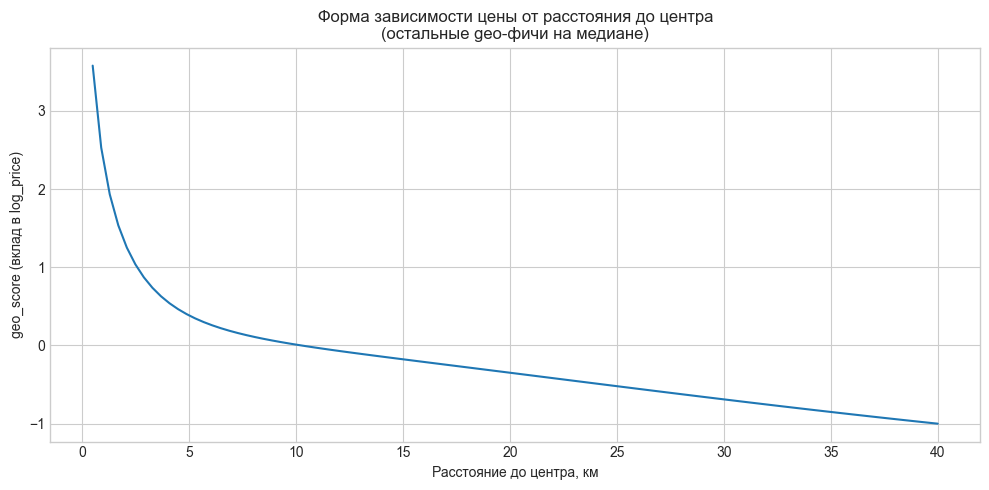

In [12]:
# Генерим синтетическую кривую: price как функция dist_center_m
import numpy as np

test_distances = np.linspace(500, 40000, 100)
test_df_synthetic = pd.DataFrame({
    "dist_center_m": test_distances,
    "log1p_dist_center_m": np.log1p(test_distances),
    "acc_center_l5000":  np.exp(-test_distances / 5000),
    "acc_center_l12000": np.exp(-test_distances / 12000),
    "acc_center_l25000": np.exp(-test_distances / 25000),
})

# Берём только центр-фичи, остальные фиксируем на медиане train
median_features = deals.loc[train_mask, geo_num_cols].median()
full_synthetic = pd.DataFrame([median_features] * 100).reset_index(drop=True)
for col in test_df_synthetic.columns:
    full_synthetic[col] = test_df_synthetic[col].values

# Предсказываем geo_score
synthetic_pred = geo_model.predict(full_synthetic[geo_num_cols])

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_distances / 1000, synthetic_pred)
ax.set_xlabel("Расстояние до центра, км")
ax.set_ylabel("geo_score (вклад в log_price)")
ax.set_title("Форма зависимости цены от расстояния до центра\n(остальные geo-фичи на медиане)")
ax.grid(True)
plt.tight_layout()
plt.show()

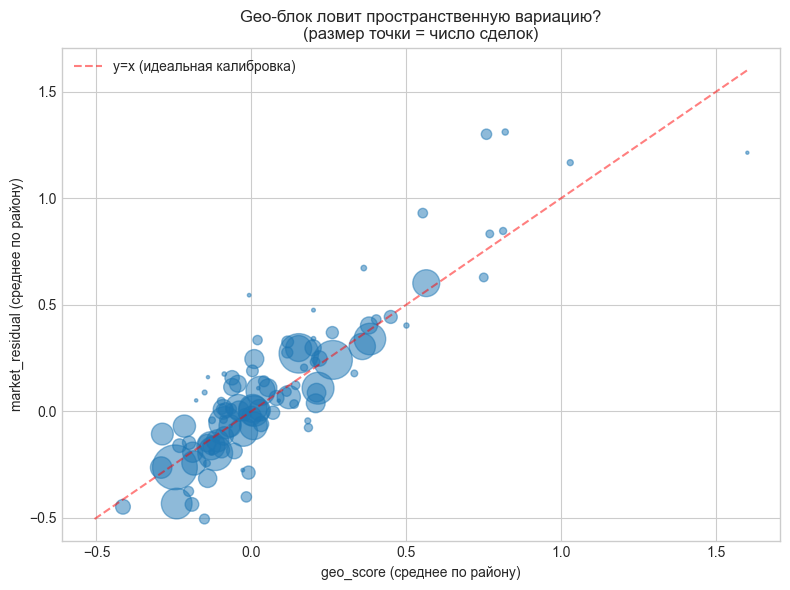

Корреляция geo_score с истинным пространственным residual: 0.880


In [13]:
# ── График: geo_score vs district (проверяем, что geo реально ловит пространство) ──
district_geo = (
    deals.loc[train_mask]
    .groupby("district_final")
    .agg(
        market_resid_mean=("market_residual", "mean"),
        geo_score_mean=("geo_score", "mean"),
        n=("market_residual", "size"),
    )
    .query("n >= 50")
    .sort_values("market_resid_mean")
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(district_geo["geo_score_mean"], district_geo["market_resid_mean"],
           s=district_geo["n"]/20, alpha=0.5)
mn = min(district_geo["geo_score_mean"].min(), district_geo["market_resid_mean"].min())
mx = max(district_geo["geo_score_mean"].max(), district_geo["market_resid_mean"].max())
ax.plot([mn, mx], [mn, mx], "r--", alpha=0.5, label="y=x (идеальная калибровка)")
ax.set_xlabel("geo_score (среднее по району)")
ax.set_ylabel("market_residual (среднее по району)")
ax.set_title("Geo-блок ловит пространственную вариацию?\n(размер точки = число сделок)")
ax.legend()
plt.tight_layout()
plt.show()

corr = district_geo[["market_resid_mean", "geo_score_mean"]].corr().iloc[0, 1]
print(f"Корреляция geo_score с истинным пространственным residual: {corr:.3f}")

## 7. Блок 3 — Quality block (GBM, без geo, без district)

Quality-модель видит **только фичи объекта и проекта**. Регрессирует `resid_after_geo`.

**Замена модели:** RidgeCV → **HistGradientBoostingRegressor**

Преимущества GBM:
- Ловит нелинейности (зависимость цены от этажа, площади)
- Взаимодействия фичей без явного задания
- Устойчив к пропускам и выбросам
- Раннее остановка по validation set

Набор фичей (идентичен baseline):
- объектные: площадь, этаж, комнаты, потолки
- проектные: возраст, стадия, масштаб
- нет geo, нет district (уже объяснены предыдущими блоками)

**Результаты исследования (project_part/summary_metrics.csv):**
- R² quality (test): 0.1251 → **0.3143** (+0.19)
- R² final (test): 0.4804 → **0.5065** (+0.026)
- MAE_log: 0.1666 → **0.1634** (better)


In [14]:
# ── Подготовка фичей объекта ─────────────────────────────────────────────
deals["rooms_num"]       = deals["rooms"].fillna(deals["rooms"].median())
deals["ceiling_m_final"] = deals["ceiling_m_pd"]
deals["floor_rel"]       = deals["floor"] / deals["floor_max_pd"].replace(0, np.nan)
deals["floor_rel"]       = deals["floor_rel"].replace([np.inf, -np.inf], np.nan)

# ── Фичи для quality-блока (те же что в baseline) ───────────────────────
quality_num_cols = [
    "area_sqm", "floor", "floor_rel", "rooms_num", "ceiling_m_final",
    "project_age_months", "months_to_rve", "lots_total",
    "area_project_total", "area_project_mean", "area_project_median",
]

quality_cat_cols = [
    "class_final", "construction_type_final", "finishing",
    # developer_final, builder_final — их роль возьмёт project_premium
]

deals = sanitize_for_sklearn(deals, quality_num_cols, quality_cat_cols)

# ── Пайплайн: числовые as-is (GBM сам умеет с NaN), кат. через OrdinalEncoder ──
quality_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), quality_num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ord",     OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]), quality_cat_cols),
])

# Индексы категориальных колонок для GBM (после трансформации они идут последними)
cat_feature_indices = list(range(len(quality_num_cols), len(quality_num_cols) + len(quality_cat_cols)))

quality_model = Pipeline([
    ("prep", quality_preprocess),
    ("reg",  HistGradientBoostingRegressor(
        max_iter=500,
        max_depth=5,
        learning_rate=0.05,
        min_samples_leaf=20,
        l2_regularization=1.0,
        max_bins=255,
        categorical_features=cat_feature_indices,
        random_state=RANDOM_STATE,
        early_stopping=True,
        n_iter_no_change=20,
        validation_fraction=0.15,
    )),
])

# ── Fit на train, target = resid_after_geo ──────────────────────────────
quality_model.fit(
    deals.loc[train_mask, quality_num_cols + quality_cat_cols],
    deals.loc[train_mask, "resid_after_geo"],
)

deals["quality_score"]       = quality_model.predict(deals[quality_num_cols + quality_cat_cols])
deals["resid_after_quality"] = deals["resid_after_geo"] - deals["quality_score"]

# ── Диагностика ─────────────────────────────────────────────────────────
r2_q_train = r2_score(deals.loc[train_mask, "resid_after_geo"], deals.loc[train_mask, "quality_score"])
r2_q_test  = r2_score(deals.loc[test_mask,  "resid_after_geo"], deals.loc[test_mask,  "quality_score"])
print(f"R\u00b2 quality (GBM) \u043d\u0430 resid_after_geo:")
print(f"  train: {r2_q_train:.4f}")
print(f"  test : {r2_q_test:.4f}")
print(f"\nGBM n_iter: {quality_model.named_steps['reg'].n_iter_}")

std_before = deals.loc[train_mask, "resid_after_geo"].std()
std_after  = deals.loc[train_mask, "resid_after_quality"].std()
print(f"\nSTD \u043e\u0441\u0442\u0430\u0442\u043a\u043e\u0432 (train):")
print(f"  \u0434\u043e quality:  {std_before:.4f}")
print(f"  \u043f\u043e\u0441\u043b\u0435:       {std_after:.4f}")
print(f"  \u0441\u043d\u0438\u0436\u0435\u043d\u0438\u0435:     {(1 - std_after/std_before)*100:.1f}%")


R² quality (GBM) на resid_after_geo:
  train: 0.7968
  test : 0.3143

GBM n_iter: 500

STD остатков (train):
  до quality:  0.2132
  после:       0.0961
  снижение:     54.9%


## 8. Блок 4 — Project premium (shrinkage)

Empirical Bayes shrinkage на остатках после всех предыдущих блоков:

$$\pi_j = \frac{n_j}{n_j + \tau}\, \bar r_j$$

Обязательно считаем средние остатки **только на train**, чтобы не утечь будущее.

In [15]:
PROJECT_PREMIUM_TAU = 20

# Агрегаты проекта только на train
proj_resid = (
    deals.loc[train_mask]
    .groupby("project_id", as_index=False)
    .agg(
        project_resid_mean=("resid_after_quality", "mean"),
        project_obs=("resid_after_quality", "size"),
        project_name=("project_name", mode_or_nan),
    )
)
proj_resid["project_premium"] = (
    proj_resid["project_obs"] / (proj_resid["project_obs"] + PROJECT_PREMIUM_TAU)
) * proj_resid["project_resid_mean"]

# Мёржим на все данные
deals = deals.drop(columns=[c for c in ["project_obs", "project_premium"] if c in deals.columns])
deals = deals.merge(
    proj_resid[["project_id", "project_obs", "project_premium"]],
    on="project_id", how="left"
)
# Для новых проектов в test (которых не было в train) — premium = 0
deals["project_premium"] = deals["project_premium"].fillna(0.0)
deals["project_obs"]     = deals["project_obs"].fillna(0)

print(f"Проектов с premium: {proj_resid.shape[0]}")
print(f"\nТоп премиальных проектов:")
display(proj_resid.sort_values("project_premium", ascending=False).head(5))
print(f"\nТоп дискаунт-проектов:")
display(proj_resid.sort_values("project_premium", ascending=True).head(5))

Проектов с premium: 508

Топ премиальных проектов:


,project_id,project_resid_mean,project_obs,project_name,project_premium
340,a9656c82bb092e41f270c174d0919023,0.274442,161,VERY,0.244116
36,13d827ab38f921b971de3db53e51d62d,0.321541,50,Дыхание,0.229672
40,14746dc8653e80be8d3388b32763f7e2,1.348403,4,Ambassador Golf Club Residence,0.224734
197,601288a2deb7851a8fc60bd9f55ba726,0.290635,62,Клубный дом на Таганке,0.219749
50,186996532fd63566ec4464cacfeb89ad,0.323943,33,Barkli Residence,0.201700



Топ дискаунт-проектов:


,project_id,project_resid_mean,project_obs,project_name,project_premium
264,7ff5556ff96a7a94d378e933b46fbfb4,-0.623106,17,Звонарский 3/4,-0.286292
89,2886cebb32dc7b6da6727ece1f218c74,-0.473045,18,Нахимовский 21,-0.224074
265,8063f81bcf7985c4564945ab7000196c,-0.204415,548,ТехноПарк,-0.197217
210,65ead21a85e19147f46c1f5dfb228d88,-0.383104,17,Kuznetsky Most 12,-0.176021
484,f3b6e2f231009034eb190bc2464dbcc0,-0.207903,77,NV/9 Artkvartal,-0.165036


In [16]:
# Сколько сделок в test имеют premium (обучен на train), а сколько — нет?
test_with_premium = deals.loc[test_mask, "project_obs"] > 0
print(f"Test сделок всего: {test_mask.sum():,}")
print(f"  с project_premium (проект был в train): {test_with_premium.sum():,} ({100*test_with_premium.mean():.1f}%)")
print(f"  без premium (новые проекты): {(~test_with_premium).sum():,} ({100*(~test_with_premium).mean():.1f}%)")

# Распределение project_premium на test
print("\nРаспределение project_premium на test:")
print(deals.loc[test_mask, "project_premium"].describe().round(3))

Test сделок всего: 231,839
  с project_premium (проект был в train): 173,192 (74.7%)
  без premium (новые проекты): 58,647 (25.3%)

Распределение project_premium на test:
count    231839.000
mean          0.007
std           0.034
min          -0.176
25%          -0.005
50%           0.000
75%           0.013
max           0.244
Name: project_premium, dtype: float64


## 9. Диагностика: вклад каждого блока

Смотрим, как падает ошибка после добавления каждого блока.

In [17]:
# ── Пошаговые предсказания ──────────────────────────────────────────────
diag = deals.loc[test_mask, ["log_price_sqm", "market_log_price",
                              "geo_score", "quality_score", "project_premium"]].copy()

diag["pred_market"]                 = diag["market_log_price"]
diag["pred_market_geo"]             = diag["pred_market"] + diag["geo_score"]
diag["pred_market_geo_quality"]     = diag["pred_market_geo"] + diag["quality_score"]
diag["pred_additive_all"]           = diag["pred_market_geo_quality"] + diag["project_premium"]

diag_metrics = pd.concat([
    regression_metrics(diag["log_price_sqm"], diag["pred_market"],             "market"),
    regression_metrics(diag["log_price_sqm"], diag["pred_market_geo"],         "+ geo"),
    regression_metrics(diag["log_price_sqm"], diag["pred_market_geo_quality"], "+ quality"),
    regression_metrics(diag["log_price_sqm"], diag["pred_additive_all"],       "+ project_premium"),
], ignore_index=True)

print("Вклад блоков (test):")
display(diag_metrics)

# ── Абсолютное улучшение от каждого блока ────────────────────────────
print("\nDelta R² от каждого блока:")
for i in range(1, len(diag_metrics)):
    delta = diag_metrics.loc[i, "R2"] - diag_metrics.loc[i-1, "R2"]
    name = diag_metrics.loc[i, "model"]
    print(f"  {name:25s}  Δ R² = {delta:+.4f}")

Вклад блоков (test):


,model,MAE_log,RMSE_log,R2,MAE_pct_approx,RMSE_pct_approx
0,market,0.256178,0.339024,0.077082,29.198316,40.357736
1,+ geo,0.214900,0.305746,0.249376,23.973730,35.763704
2,+ quality,0.167139,0.253161,0.485371,18.191856,28.809010
3,+ project_premium,0.163507,0.249575,0.499845,17.763313,28.348009



Delta R² от каждого блока:
  + geo                      Δ R² = +0.1723
  + quality                  Δ R² = +0.2360
  + project_premium          Δ R² = +0.0145


## 10. Финальная ElasticNet — калибровка блоков

Берём все уже построенные блоки как входные фичи + немного сырых колонок для точной подстройки. ElasticNet просто найдёт оптимальные веса.

In [18]:
final_num_cols = [
    "market_log_price",   # временной тренд
    "geo_score",          # пространственная премия
    "quality_score",      # качество объекта/проекта
    "project_premium",    # shrinkage-остаток проекта
    # плюс немного сырых фичей для тонкой калибровки
    "area_sqm", "floor", "floor_rel", "rooms_num",
]

final_cat_cols = [
    "class_final",  # на всякий случай — класс иногда требует корректировки
]

feature_cols = final_num_cols + final_cat_cols
target_col   = "log_price_sqm"

train_df = deals.loc[train_mask].copy()
test_df  = deals.loc[test_mask].copy()
print(f"train: {train_df.shape}")
print(f"test : {test_df.shape}")

final_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), final_num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe",     OneHotEncoder(handle_unknown="ignore", min_frequency=10)),
    ]), final_cat_cols),
])

final_model = Pipeline([
    ("prep", final_preprocess),
    ("reg",  ElasticNetCV(
        l1_ratio=[0.05, 0.2, 0.5, 0.8, 0.95],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=RANDOM_STATE,
        max_iter=5000,
        n_jobs=-1,
    )),
])

baseline_pred = np.repeat(train_df[target_col].median(), len(test_df))
final_model.fit(train_df[feature_cols], train_df[target_col])
pred_test = final_model.predict(test_df[feature_cols])

metrics_df = pd.concat([
    regression_metrics(test_df[target_col], baseline_pred, "baseline_median"),
    regression_metrics(test_df[target_col], pred_test,     "final_elastic_net"),
], ignore_index=True)

display(metrics_df)

# ── Коэффициенты финальной модели ───────────────────────────────────────
coefs_final = extract_coefs(final_model, final_num_cols, final_cat_cols)
print("\nКоэффициенты финальной модели (топ-15 по |coef|):")
print(coefs_final.reindex(coefs_final.abs().sort_values(ascending=False).index).head(15).round(4))

train: (345566, 128)
test : (231839, 128)


,model,MAE_log,RMSE_log,R2,MAE_pct_approx,RMSE_pct_approx
0,baseline_median,0.611651,0.701120,-2.947170,84.347234,101.600848
1,final_elastic_net,0.163437,0.247921,0.506452,17.755122,28.135922



Коэффициенты финальной модели (топ-15 по |coef|):
market_log_price        0.2349
geo_score               0.2320
quality_score           0.1799
project_premium         0.0291
class_final_comfort    -0.0001
rooms_num               0.0000
floor                   0.0000
area_sqm                0.0000
floor_rel              -0.0000
class_final_business    0.0000
class_final_economy    -0.0000
class_final_premium     0.0000
dtype: float64


## 11. Оценка и визуализация

Median APE: 0.1292
Mean APE  : 0.1667
P90 APE   : 0.3208


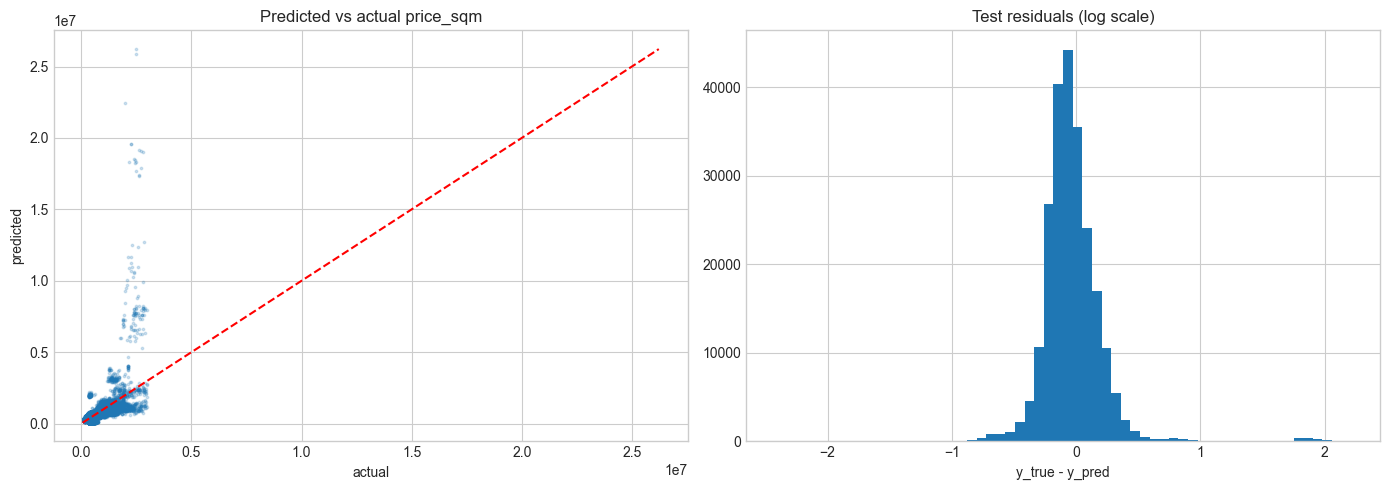

In [19]:
test_eval = test_df[[
    "project_name", "district_final", "quarter",
    "price_sqm", "market_log_price", "geo_score", "quality_score", "project_premium"
]].copy()
test_eval["pred_log_price_sqm"] = pred_test
test_eval["pred_price_sqm"]     = np.exp(test_eval["pred_log_price_sqm"])
test_eval["ape"] = (test_eval["pred_price_sqm"] - test_eval["price_sqm"]).abs() / test_eval["price_sqm"]

print(f"Median APE: {test_eval['ape'].median():.4f}")
print(f"Mean APE  : {test_eval['ape'].mean():.4f}")
print(f"P90 APE   : {test_eval['ape'].quantile(0.9):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(test_df["price_sqm"], test_eval["pred_price_sqm"], alpha=0.2, s=3)
mn = min(test_df["price_sqm"].min(), test_eval["pred_price_sqm"].min())
mx = max(test_df["price_sqm"].max(), test_eval["pred_price_sqm"].max())
axes[0].plot([mn, mx], [mn, mx], "r--")
axes[0].set_title("Predicted vs actual price_sqm")
axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")

resid = test_df["log_price_sqm"].values - pred_test
axes[1].hist(resid, bins=60)
axes[1].set_title("Test residuals (log scale)")
axes[1].set_xlabel("y_true - y_pred")

plt.tight_layout()
plt.show()

## 12. Сравнение с прошлой версией

Смотрим, даёт ли новая архитектура с outlined geo-блоком улучшение по сравнению с одной большой регрессией.

In [20]:
# ── Проверка: сколько на самом деле даёт geo_score ────────────────────
# Сравним: market+quality без geo vs market+geo+quality

# Обучаем quality_model альтернативный: market_residual (не resid_after_geo) как target
quality_model_no_geo = Pipeline([
    ("prep", quality_preprocess),
    ("reg",  RidgeCV(alphas=np.logspace(-3, 3, 15))),
])
quality_model_no_geo.fit(
    deals.loc[train_mask, quality_num_cols + quality_cat_cols],
    deals.loc[train_mask, "market_residual"],
)
deals["quality_score_no_geo"] = quality_model_no_geo.predict(
    deals[quality_num_cols + quality_cat_cols]
)

# Вариант A: market + quality (без geo)
pred_A = deals.loc[test_mask, "market_log_price"] + deals.loc[test_mask, "quality_score_no_geo"]
# Вариант B: market + geo + quality
pred_B = (deals.loc[test_mask, "market_log_price"]
          + deals.loc[test_mask, "geo_score"]
          + deals.loc[test_mask, "quality_score"])

y_true = deals.loc[test_mask, "log_price_sqm"]

comparison = pd.concat([
    regression_metrics(y_true, pred_A, "market + quality (без geo)"),
    regression_metrics(y_true, pred_B, "market + geo + quality"),
], ignore_index=True)

print("Честное сравнение вклада geo-блока:")
display(comparison)

delta_r2 = comparison.loc[1, "R2"] - comparison.loc[0, "R2"]
delta_mae = comparison.loc[0, "MAE_log"] - comparison.loc[1, "MAE_log"]
print(f"\nВклад geo-блока:")
print(f"  Δ R²      = {delta_r2:+.4f}")
print(f"  Δ MAE_log = {delta_mae:+.4f}")
print(f"  Δ MAE (%) = {100*(np.exp(comparison.loc[0,'MAE_log']) - np.exp(comparison.loc[1,'MAE_log'])):+.2f} п.п.")

Честное сравнение вклада geo-блока:


,model,MAE_log,RMSE_log,R2,MAE_pct_approx,RMSE_pct_approx
0,market + quality (без geo),0.197424,0.252199,0.489272,21.826106,28.685265
1,market + geo + quality,0.167139,0.253161,0.485371,18.191856,28.809010



Вклад geo-блока:
  Δ R²      = -0.0039
  Δ MAE_log = +0.0303
  Δ MAE (%) = +3.63 п.п.


## 13. Сохранение артефактов

In [21]:
# import pickle

# ARTIFACTS_DIR = PROJECT_DIR / "data" / "model_artifacts"
# ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# # Сохраняем все модели
# with open(ARTIFACTS_DIR / f"final_model_{REGION_KEY}.pkl", "wb") as f:
#     pickle.dump(final_model, f)

# with open(ARTIFACTS_DIR / f"geo_model_{REGION_KEY}.pkl", "wb") as f:
#     pickle.dump(geo_model, f)

# with open(ARTIFACTS_DIR / f"quality_model_{REGION_KEY}.pkl", "wb") as f:
#     pickle.dump(quality_model, f)

# # PCA компоненты
# with open(ARTIFACTS_DIR / f"pca_geo_{REGION_KEY}.pkl", "wb") as f:
#     pickle.dump({"pca": pca_geo, "scaler": pca_scaler, "input_cols": pca_input_cols}, f)

# proj_resid.to_parquet(ARTIFACTS_DIR / f"project_premium_{REGION_KEY}.parquet", index=False)

# market_index = (
#     deals[["quarter", "city_log_price_median", "market_log_price"]]
#     .drop_duplicates()
#     .reset_index(drop=True)
# )
# market_index.to_parquet(ARTIFACTS_DIR / f"market_index_{REGION_KEY}.parquet", index=False)

# # Коэффициенты geo для интерпретации
# coefs_geo.sort_values(key=abs, ascending=False).to_csv(
#     ARTIFACTS_DIR / f"geo_coefs_{REGION_KEY}.csv"
# )

# print(f"Модели и артефакты сохранены в: {ARTIFACTS_DIR}")
# print(f"\nФинальные метрики:")
# display(metrics_df)
# print(f"\nВклад блоков:")
# display(diag_metrics)